# Ejercicio Regression Tree
Son datos de temperaturas tomados de la ciudad de Seattle. El objetivo es intentar predecir lo mejor posible la máxima temperatura (columna `actual`) que alcanzaremos al día siguiente. Para ello contaremos con temperaturas de los dos días anteriores, históricos de máximas temperaturas y un amigo bastante chapas que te da su predicción del tiempo cada día.

**Resumen de datos**:
* year: 2016 for all data points
* month: number for month of the year
* day: number for day of the year
* week: day of the week as a character string
* temp_2: max temperature 2 days prior
* temp_1: max temperature 1 day prior
* average: historical average max temperature
* actual: max temperature measurement
* friend: your friend’s prediction, a random number between 20 below the average and 20 above the average


### 1. Importa el csv "temps.csv"

In [152]:
# to make this notebook's output stable across runs
np.random.seed(42)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import sklearn

# To plot pretty figures
# %matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

In [153]:
# Cargar el dataset:
df = pd.read_csv('data/temps.csv')
# Comprobar que el dataset se ha cargado correctamente:
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend
0,2016,1,1,Fri,45,45,45.6,45,29
1,2016,1,2,Sat,44,45,45.7,44,61
2,2016,1,3,Sun,45,44,45.8,41,56
3,2016,1,4,Mon,44,41,45.9,40,53
4,2016,1,5,Tues,41,40,46.0,44,41


In [154]:
# Mirar si hay valores nulos y tipo de variables:
df.info()
# No hay valores nulos, todas las variables son numéricas menos week, que es un string (categorica)

<class 'pandas.DataFrame'>
RangeIndex: 348 entries, 0 to 347
Data columns (total 9 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   year     348 non-null    int64  
 1   month    348 non-null    int64  
 2   day      348 non-null    int64  
 3   week     348 non-null    str    
 4   temp_2   348 non-null    int64  
 5   temp_1   348 non-null    int64  
 6   average  348 non-null    float64
 7   actual   348 non-null    int64  
 8   friend   348 non-null    int64  
dtypes: float64(1), int64(7), str(1)
memory usage: 24.6 KB


### 2. Realiza un análisis exploratorio junto con un Feature Engineering

In [155]:
# Observar las estadísticas descriptivas del dataset:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
year,348.0,2016.000000,0.000000,2016.0,2016.000,2016.0,2016.000,2016.0
month,348.0,6.477011,3.498380,1.0,3.000,6.0,10.000,12.0
day,348.0,15.514368,8.772982,1.0,8.000,15.0,23.000,31.0
temp_2,348.0,62.652299,12.165398,35.0,54.000,62.5,71.000,117.0
temp_1,348.0,62.701149,12.120542,35.0,54.000,62.5,71.000,117.0
average,348.0,59.760632,10.527306,45.1,49.975,58.2,69.025,77.4
actual,348.0,62.543103,11.794146,35.0,54.000,62.5,71.000,92.0
friend,348.0,60.034483,15.626179,28.0,47.750,60.0,71.000,95.0


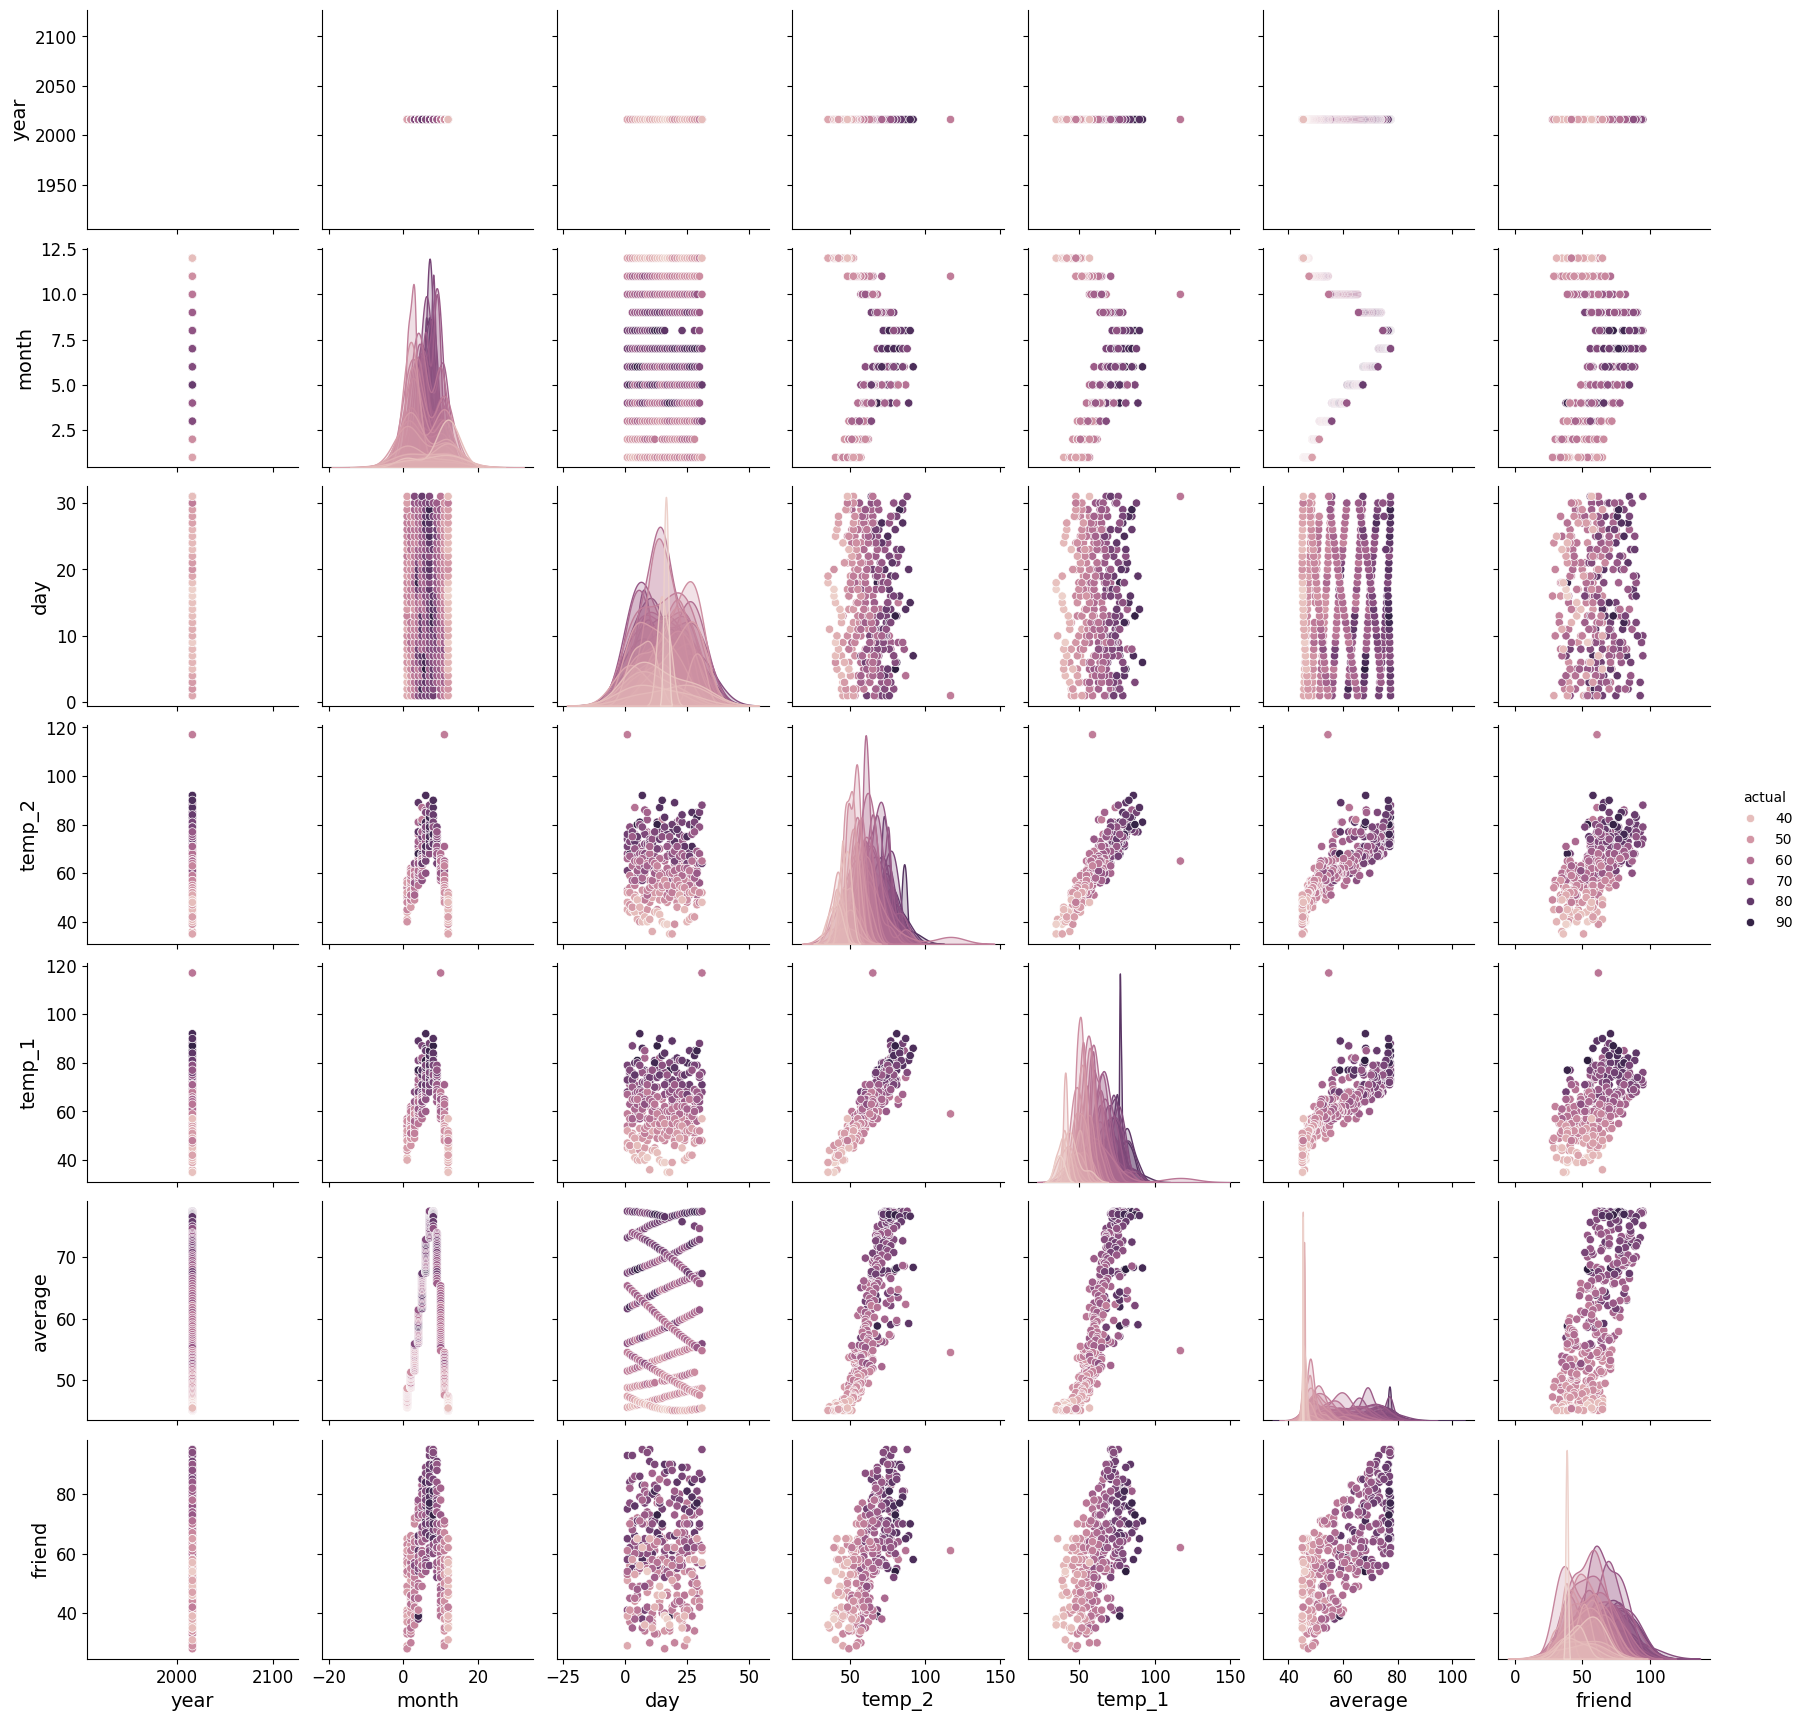

In [156]:
sns.pairplot(df,hue='actual');

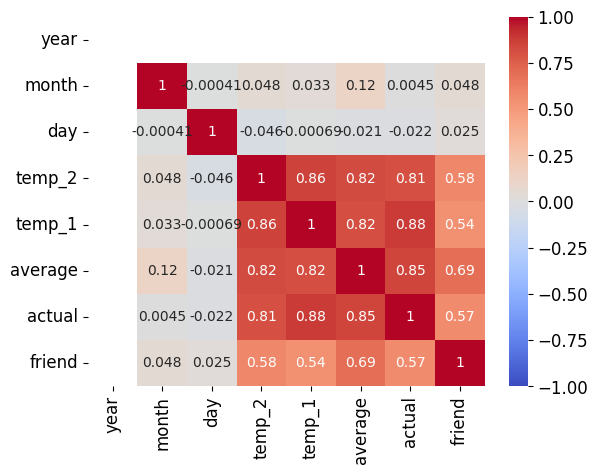

In [157]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1);

In [117]:
# Mirar los valores únicos de la variable 'week':
df['week'].unique()

<StringArray>
['Fri', 'Sat', 'Sun', 'Mon', 'Tues', 'Wed', 'Thurs']
Length: 7, dtype: str

In [118]:
# Convertir la variable 'week' a numérica usando label encoding:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
df['week_encoded'] = encoder.fit_transform(df['week'])
df.head()

,year,month,day,week,temp_2,temp_1,average,actual,friend,week_encoded
0,2016,1,1,Fri,45,45,45.6,45,29,0
1,2016,1,2,Sat,44,45,45.7,44,61,2
2,2016,1,3,Sun,45,44,45.8,41,56,3
3,2016,1,4,Mon,44,41,45.9,40,53,1
4,2016,1,5,Tues,41,40,46.0,44,41,5


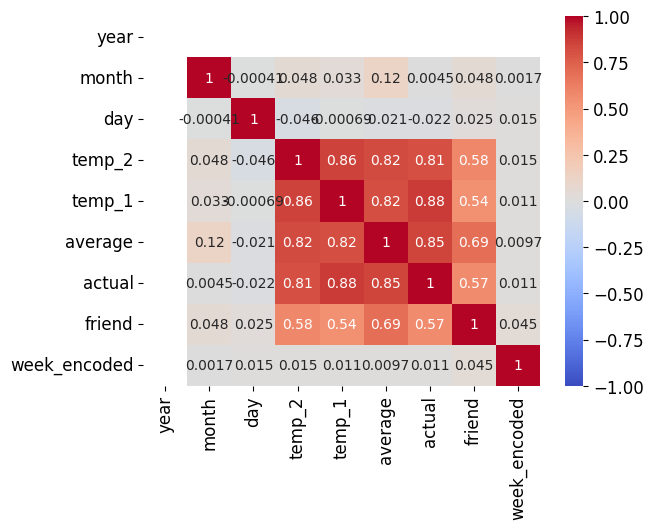

In [119]:
# Heatmap con la nueva variable 'week_encoded':
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", vmin=-1);

In [100]:
# Viendo que las variables year, month y week_encoded no tienen una correlación alta con la variable objetivo 'actual', 
# se decide eliminarlas del dataset para simplificar el modelo.

### 3. Selecciona variables y divide en train y test

In [ ]:
# Comprobar mis variables:
df.columns

Index(['year', 'month', 'day', 'week', 'temp_2', 'temp_1', 'average', 'actual',
       'friend', 'week_encoded'],
      dtype='str')

In [121]:
# Definir las variables predictoras (X) y la variable objetivo (y):
features = ['temp_1','temp_2','average','friend']
X = df[features]
y = df['actual']

In [ ]:
# Dividir el dataset en conjunto de train y conjunto de test, dejando un 20% de los datos para test:
from sklearn.model_selection import train_test_split
from sklearn import model_selection

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.2, random_state=42)

In [123]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(278, 4)
(70, 4)
(278,)
(70,)


In [124]:
# Escalado de las variables numéricas:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scal = scaler.fit_transform(X_train)
X_test_scal = scaler.transform(X_test)

### 4. Entrena el modelo


In [ ]:
# Entrenar el modelo de árbol de decisión:
from sklearn.tree import DecisionTreeRegressor
arbol = DecisionTreeRegressor(max_depth=2,
                                  random_state=42)
arbol.fit(X_train_scal, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",2
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [135]:
y_pred = arbol.predict(X_test_scal)

### 5. Evaluación de tu modelo
Calcula el coeficiente de determinación. 

Calcula el MAE, MAPE, MSE y RMSE.

In [ ]:
# Evaluar el modelo con las métricas de regresión:
import numpy as np
from sklearn import metrics

print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))
print('R²:', metrics.r2_score(y_test, y_pred))

MAE: 4.888811585240156
MSE: 37.64787660374395
RMSE: 6.135786551351338
MAPE: 0.07740495191086964
R²: 0.7307506227036282


In [ ]:
# Las métricas nos indican que el modelo explica el 73% de la variabilidad de los datos, lo cual no está nada mal. 

### 6. Representa el árbol de decisión

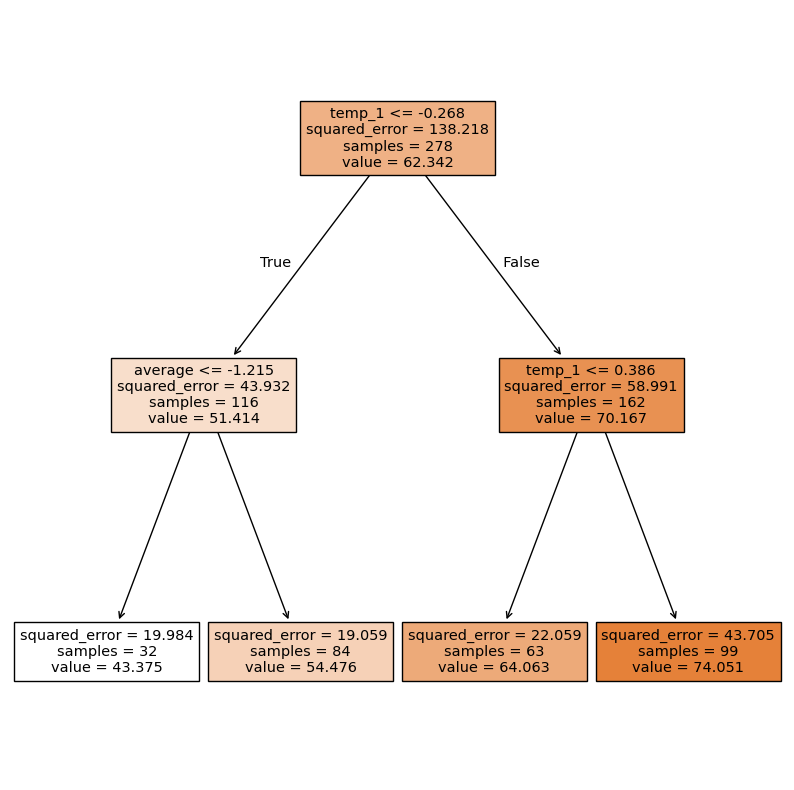

In [142]:
# Representar árbol de decisión:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
plot_tree(arbol, feature_names=features, filled=True)
plt.show();

### 7. Modifica el max_depth a 3 y vuelve a entrenarlo

In [145]:
from sklearn.tree import DecisionTreeRegressor
arbol = DecisionTreeRegressor(max_depth=3,
                                  random_state=42)
arbol.fit(X_train_scal, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",3
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf

In [146]:
y_pred = arbol.predict(X_test_scal)

### 8. Vuelve a evaluar tu modelo

In [147]:
print('MAE:', metrics.mean_absolute_error(y_test, y_pred))
print('MSE:', metrics.mean_squared_error(y_test, y_pred))
print('RMSE:', np.sqrt(metrics.mean_squared_error(y_test, y_pred)))
print('MAPE:', metrics.mean_absolute_percentage_error(y_test, y_pred))
print('R²:', metrics.r2_score(y_test, y_pred))

MAE: 4.267242249556827
MSE: 30.946461197509944
RMSE: 5.5629543587476915
MAPE: 0.0674392768128964
R²: 0.7786776796296856


### 9. Vuelve a representar su árbol

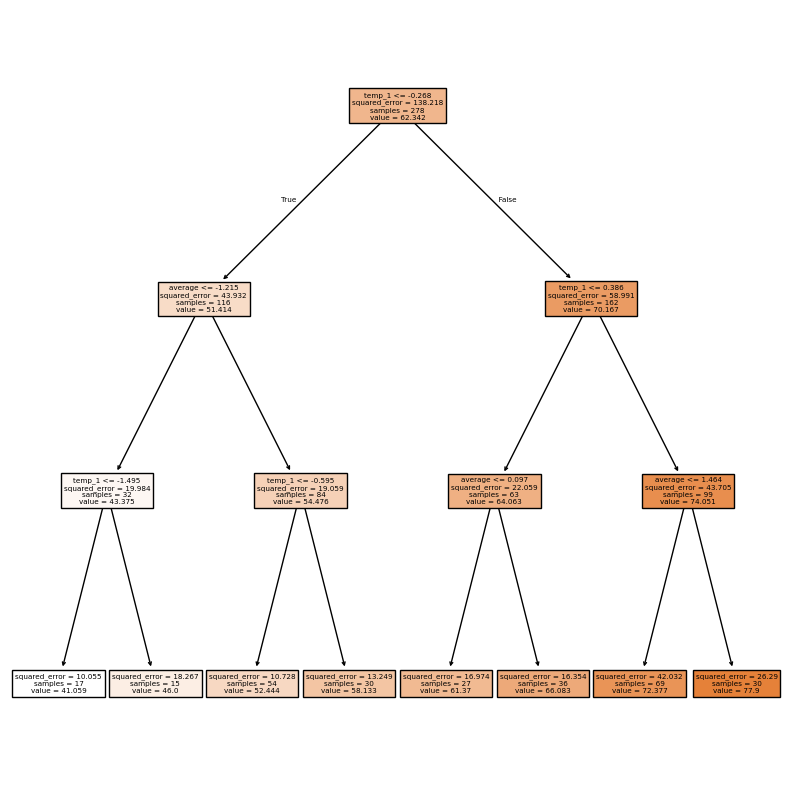

In [148]:
# Representar árbol de decisión:
from sklearn.tree import plot_tree
plt.figure(figsize=(10,10))
plot_tree(arbol, feature_names=features, filled=True)
plt.show();

### 10. Utiliza un grid search con cross validation para hiperparametrizar tu modelo

In [149]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [2, 3, 4, 5, 6],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42),
                           param_grid, cv=5, scoring='neg_mean_squared_error')
grid_search.fit(X_train_scal, y_train)
print("Mejores parámetros:", grid_search.best_params_)

Mejores parámetros: {'max_depth': 4, 'min_samples_leaf': 4, 'min_samples_split': 2}


### 11. Obten el `feature_importances` de cada variable en el último modelo

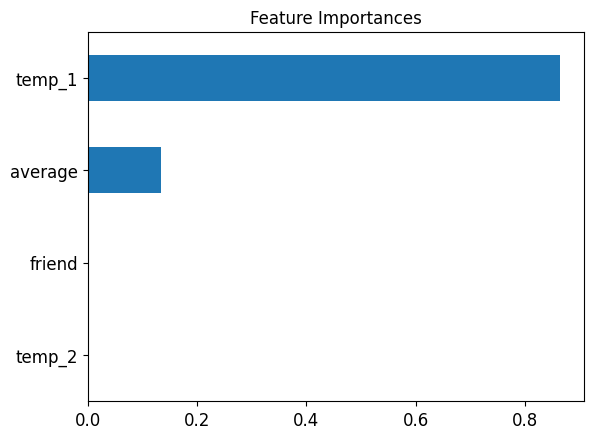

In [150]:
best_model = grid_search.best_estimator_
importances = pd.Series(best_model.feature_importances_, index=features)
importances.sort_values().plot(kind='barh')
plt.title("Feature Importances")
plt.show()

### 12. Construye un nuevo modelo `DecisionTreeClassifier` que te clasifique cuando en un día va a hacer una temperatura mayor a 15ºC (59ºF). ¡Deberá tratarse como un problema de **clasificación**! Utiliza un grid search con cross validation y evalúa el mejor modelo.

In [151]:
from sklearn.tree import DecisionTreeClassifier

y_clase = (y > 15).astype(int)  # 1 si >15°C, 0 si no
X_train2, X_test2, y_train2, y_test2 = train_test_split(X, y_clase, test_size=0.2, random_state=42)

param_grid_clf = {'max_depth': [2, 3, 4, 5]}
grid_clf = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_clf, cv=5, scoring='accuracy')
grid_clf.fit(X_train2, y_train2)

print("Mejores parámetros:", grid_clf.best_params_)
print("Accuracy:", grid_clf.best_score_)

Mejores parámetros: {'max_depth': 2}
Accuracy: 1.0
